# Cloud Cover Threshold Comparison: RF vs SVM vs XGBoost

This notebook sweeps different CLOUDY_PIXEL_PERCENTAGE thresholds across all three
classifiers to demonstrate that **x% of cloud cover** yields the best classification accuracy.

> Uses the same training points, bands, and classifier hyperparameters as the
> individual notebooks in `nb/rf/`, `nb/svm/`, and `nb/xgb/`.

In [1]:
import sys; sys.path.insert(0, '../nb')
from shared.training_pipeline import init_ee
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

init_ee()


/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/ashutoshsaxena/Desktop/ml-central/Geo-Engine-Classifier/.venv/lib/python3.9/site-packages/google/api_core/_py

Earth Engine initialized successfully.


### Campus Boundary

In [2]:
import ee
from shared.training_pipeline import get_campus_geometry

campus = get_campus_geometry()


### Cloud Mask & Helpers

In [3]:
from shared.training_pipeline import mask_s2_clouds, BANDS, SEED

bands = BANDS


### Load Training Points

In [4]:
from shared.training_pipeline import load_training_points

forest_points, non_forest_points, training_points = load_training_points()

print(f"Forest points:     {forest_points.size().getInfo()}")
print(f"Non-forest points: {non_forest_points.size().getInfo()}")


Forest points:     250
Non-forest points: 250


### Define Classifiers & Cloud Cover Thresholds

In [5]:
from shared.training_pipeline import get_classifier_factories

CLOUD_COVER_VALUES = [5, 10, 15, 20, 30, 50]

CLASSIFIERS = get_classifier_factories()

print(f"Classifiers: {list(CLASSIFIERS.keys())}")
print(f"Cloud Cover Thresholds: {CLOUD_COVER_VALUES}")

Classifiers: ['Random Forest', 'SVM (RBF)', 'Gradient Boosted Trees']
Cloud Cover Thresholds: [1, 2, 3, 5, 10, 15, 20, 30, 50]


### Run Cloud Cover Sweep

In [6]:
results = []

for cc in CLOUD_COVER_VALUES:
    print(f"{'='*60}")
    print(f"  Cloud Cover Threshold: {cc}%")
    print(f"{'='*60}")

    # Build the image for this cloud cover threshold
    dataset = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
               .filterDate('2025-09-01', '2025-10-31')
               .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', cc))
               .map(mask_s2_clouds))

    image_count = dataset.size().getInfo()
    print(f"  Available images: {image_count}")

    if image_count == 0:
        print(f"  ⚠ No images found for {cc}% threshold – skipping")
        for clf_name in CLASSIFIERS:
            results.append({
                'cloud_cover': cc, 'classifier': clf_name,
                'accuracy': None, 'kappa': None, 'image_count': 0,
            })
        continue

    image = dataset.median().clip(campus)

    # Add NDVI
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    image = image.addBands(ndvi)

    # Sample and split using shared pipeline
    from shared.training_pipeline import sample_and_split
    train_set, test_set = sample_and_split(image, training_points, bands)

    for clf_name, clf_factory in CLASSIFIERS.items():
        try:
            classifier = clf_factory().train(
                features=train_set,
                classProperty='label',
                inputProperties=bands
            )

            validated = test_set.classify(classifier)
            cm = validated.errorMatrix('label', 'classification')
            accuracy = cm.accuracy().getInfo()
            kappa = cm.kappa().getInfo()

            print(f"  {clf_name:30s}  Accuracy: {accuracy:.4f}   Kappa: {kappa:.4f}")

            results.append({
                'cloud_cover': cc, 'classifier': clf_name,
                'accuracy': accuracy, 'kappa': kappa, 'image_count': image_count,
            })
        except Exception as e:
            print(f"  {clf_name:30s}  ERROR: {e}")
            results.append({
                'cloud_cover': cc, 'classifier': clf_name,
                'accuracy': None, 'kappa': None, 'image_count': image_count,
            })

print("✅ Sweep complete!")

  Cloud Cover Threshold: 1%
  Available images: 117369
  Random Forest                   Accuracy: 1.0000   Kappa: 1.0000
  SVM (RBF)                       Accuracy: 0.9610   Kappa: 0.9221
  Gradient Boosted Trees          Accuracy: 0.9870   Kappa: 0.9740
  Cloud Cover Threshold: 2%
  Available images: 134394


### Results Table

In [7]:
df = pd.DataFrame(results)
print(df[['cloud_cover', 'classifier', 'accuracy', 'kappa', 'image_count']].to_string(index=False))

 cloud_cover             classifier  accuracy    kappa  image_count
           1          Random Forest  0.993506 0.987013       117369
           1              SVM (RBF)  0.980519 0.961052       117369
           1 Gradient Boosted Trees  0.980519 0.961039       117369
           2          Random Forest  0.956835 0.913700       134394
           2              SVM (RBF)  0.978417 0.956828       134394
           2 Gradient Boosted Trees  0.971223 0.942443       134394
           3          Random Forest  0.958333 0.916328       146873
           3              SVM (RBF)  0.951389 0.902326       146873
           3 Gradient Boosted Trees  0.951389 0.902439       146873
           5          Random Forest  0.958333 0.916618       167125
           5              SVM (RBF)  0.958333 0.916683       167125
           5 Gradient Boosted Trees  0.958333 0.916586       167125
          10          Random Forest  0.969925 0.939778       205610
          10              SVM (RBF)  0.962406 0.

### Accuracy & Kappa vs Cloud Cover

FileNotFoundError: [Errno 2] No such file or directory: 'fe/cloud_cover_comparison.png'

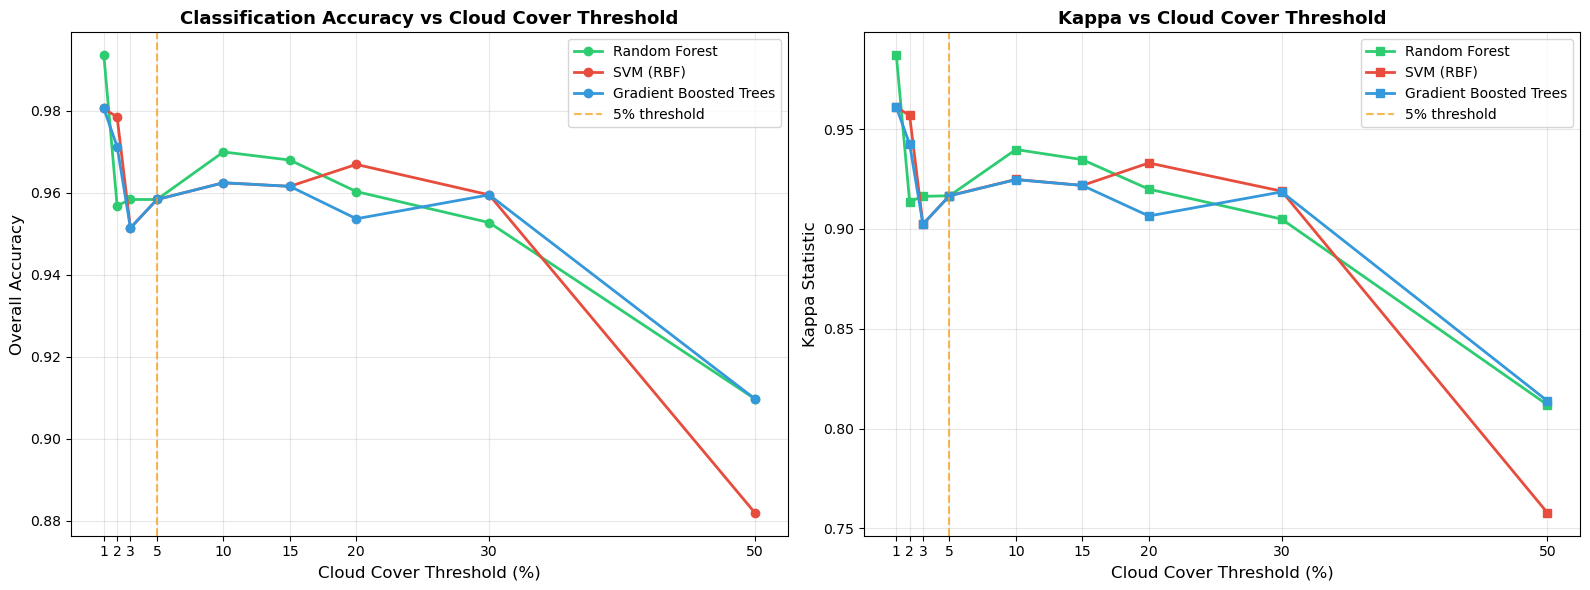

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = {
    "Random Forest": "#2ecc71",
    "SVM (RBF)": "#e74c3c",
    "Gradient Boosted Trees": "#3498db",
}

# --- Accuracy plot ---
ax1 = axes[0]
for clf_name in CLASSIFIERS:
    subset = df[df['classifier'] == clf_name].dropna(subset=['accuracy'])
    ax1.plot(subset['cloud_cover'], subset['accuracy'],
             marker='o', linewidth=2, label=clf_name,
             color=colors[clf_name])

ax1.axvline(x=5, color='#f39c12', linestyle='--', linewidth=1.5,
            alpha=0.7, label='5% threshold')
ax1.set_xlabel('Cloud Cover Threshold (%)', fontsize=12)
ax1.set_ylabel('Overall Accuracy', fontsize=12)
ax1.set_title('Classification Accuracy vs Cloud Cover Threshold', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(CLOUD_COVER_VALUES)

# --- Kappa plot ---
ax2 = axes[1]
for clf_name in CLASSIFIERS:
    subset = df[df['classifier'] == clf_name].dropna(subset=['kappa'])
    ax2.plot(subset['cloud_cover'], subset['kappa'],
             marker='s', linewidth=2, label=clf_name,
             color=colors[clf_name])

ax2.axvline(x=5, color='#f39c12', linestyle='--', linewidth=1.5,
            alpha=0.7, label='5% threshold')
ax2.set_xlabel('Cloud Cover Threshold (%)', fontsize=12)
ax2.set_ylabel('Kappa Statistic', fontsize=12)
ax2.set_title('Kappa vs Cloud Cover Threshold', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(CLOUD_COVER_VALUES)

plt.tight_layout()
plt.savefig('fe/cloud_cover_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: fe/cloud_cover_comparison.png")

### Best Threshold Summary

In [9]:
# Save CSV
df.to_csv('fe/cloud_cover_results.csv', index=False)
print("Saved: fe/cloud_cover_results.csv")

print("" + "="*70)
print("  BEST CLOUD COVER THRESHOLD PER CLASSIFIER")
print("="*70)
for clf_name in CLASSIFIERS:
    subset = df[(df['classifier'] == clf_name) & df['accuracy'].notna()]
    if not subset.empty:
        best = subset.loc[subset['accuracy'].idxmax()]
        print(f"  {clf_name:30s}  Best CC: {int(best['cloud_cover']):>3d}%"
              f"  Accuracy: {best['accuracy']:.4f}   Kappa: {best['kappa']:.4f}")

print("✅ Done!")

OSError: Cannot save file into a non-existent directory: 'fe'